# Multiple Linear Regression - Exercise

You are given a real estate dataset. 

Real estate is one of those examples that every regression course goes through as it is extremely easy to understand and there is a (almost always) certain causal relationship to be found.

The data is located in the file: 'real_estate_price_size_year.csv'. 

You are expected to create a multiple linear regression (similar to the one in the lecture), using the new data. 

In this exercise, the dependent variable is 'price', while the independent variables are 'size' and 'year'.

Good luck!

## Import the relevant libraries

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from matplotlib.projections import get_projection_names
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

sns.set_theme()

## Load the data

In [12]:
data = pd.read_csv("real_estate_price_size_year.csv")

In [18]:
data.describe()

,price,size,year
count,100.000000,100.000000,100.000000
mean,292289.470160,853.024200,2012.600000
std,77051.727525,297.941951,4.729021
min,154282.128000,479.750000,2006.000000
25%,234280.148000,643.330000,2009.000000
50%,280590.716000,696.405000,2015.000000
75%,335723.696000,1029.322500,2018.000000
max,500681.128000,1842.510000,2018.000000


## Create the regression

### Declare the dependent and the independent variables

In [14]:
endog = data["price"]
exog  = add_constant(data[["size", "year"]])

### Regression

In [15]:
model = OLS(
    endog=endog,
    exog=exog,
    hasconst=True
).fit()

In [51]:
summary = model.summary()

In [55]:
print(summary.as_text())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     168.5
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           2.77e-32
Time:                        22:13:29   Log-Likelihood:                -1191.7
No. Observations:                 100   AIC:                             2389.
Df Residuals:                      97   BIC:                             2397.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.772e+06   1.58e+06     -3.647      0.0

In [40]:
model.params

const   -5.772267e+06
size     2.277009e+02
year     2.916785e+03
dtype: float64

### Visualisation

['3d', 'aitoff', 'hammer', 'lambert', 'mollweide', 'polar', 'rectilinear']

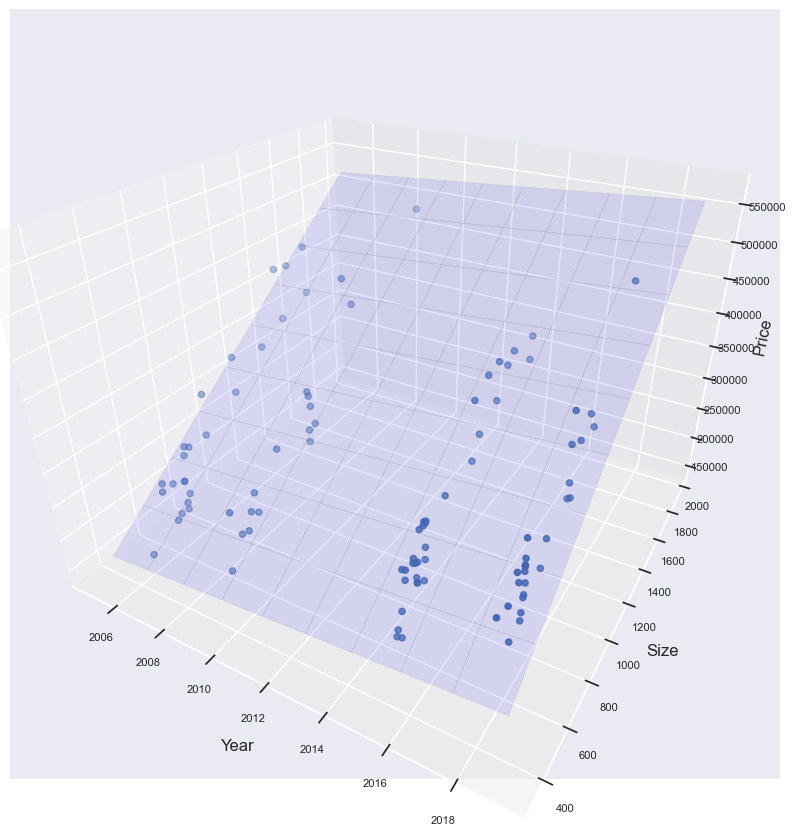

In [47]:
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection": "3d"})

ax.scatter(
    data["year"],
    data["size"],
    data["price"])

ax.set_xlabel("Year")
ax.set_ylabel("Size")
ax.set_zlabel("Price")
ax.tick_params(labelsize=8)

xmin, xmax = ax.get_xlim3d()
ymin, ymax = ax.get_ylim3d()
zmin, zmax = ax.get_zlim3d()

X, Y = np.meshgrid(np.linspace(xmin, xmax, 10), np.linspace(ymin, ymax, 10))
Z = model.params["year"] * X + model.params["size"] * Y + model.params["const"]

ax.plot_surface(X, Y, Z, alpha=0.1, color='blue', edgecolor='black', linewidth=0.3)

ax.set_proj_type("persp", focal_length=0.2)

plt.show()